# 🎭 Three-Model Pose Detection Comparison

**Academic Project**: Real-time comparison of three pose detection systems

## Models Being Compared:
1. **MediaPipe Pose** - Baseline (33 body landmarks)
2. **MediaPipe Pose + Face Mesh** - Enhanced (33 body + 478 face landmarks)
3. **OpenPose** - Industry Standard (25 body + 70 face keypoints)

---

## 📦 Step 1: Import Libraries

In [2]:
# Ensure required packages exist in the *current* notebook kernel.
# Using --user flag to avoid permission issues.

%pip -q install --user numpy pandas matplotlib mediapipe jinja2

# Quick sanity check
import cv2
import numpy as np
import pandas as pd
import matplotlib
import mediapipe as mp
import jinja2
print(f"✓ OpenCV: {cv2.__version__}")
print(f"✓ NumPy: {np.__version__}")
print(f"✓ Pandas: {pd.__version__}")
print(f"✓ Matplotlib: {matplotlib.__version__}")
print(f"✓ MediaPipe: {mp.__version__}")
print(f"✓ Jinja2: {jinja2.__version__}")


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✓ OpenCV: 4.13.0
✓ NumPy: 2.2.6
✓ Pandas: 2.3.3
✓ Matplotlib: 3.10.8
✓ MediaPipe: 0.10.32
✓ Jinja2: 3.1.6


In [3]:
# Core libraries
import cv2
import numpy as np
import time
import os
import datetime
from IPython.display import Image, display, clear_output
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd

# MediaPipe
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# OpenPose (optional)
try:
    import pyopenpose as op
    OPENPOSE_AVAILABLE = True
    print("✓ OpenPose available")
except ImportError:
    OPENPOSE_AVAILABLE = False
    print("⚠ OpenPose not available (will use MediaPipe models only)")

print("✓ All core libraries imported successfully!")
print(f"  - OpenCV version: {cv2.__version__}")
print(f"  - MediaPipe version: {mp.__version__}")
print(f"  - NumPy version: {np.__version__}")

⚠ OpenPose not available (will use MediaPipe models only)
✓ All core libraries imported successfully!
  - OpenCV version: 4.13.0
  - MediaPipe version: 0.10.32
  - NumPy version: 2.2.6


## 🔧 Step 2: Initialize All Models

In [4]:
# Model paths
POSE_MODEL_PATH = 'pose_landmarker_full.task'
FACE_MODEL_PATH = 'face_landmarker.task'

# Verify model files exist
if not os.path.exists(POSE_MODEL_PATH):
    raise FileNotFoundError(f"Pose model not found: {POSE_MODEL_PATH}")
if not os.path.exists(FACE_MODEL_PATH):
    raise FileNotFoundError(f"Face model not found: {FACE_MODEL_PATH}")

print("✓ Model files found")
print(f"  - Pose: {os.path.getsize(POSE_MODEL_PATH) / (1024*1024):.1f} MB")
print(f"  - Face: {os.path.getsize(FACE_MODEL_PATH) / (1024*1024):.1f} MB")

✓ Model files found
  - Pose: 9.0 MB
  - Face: 3.6 MB


### Initialize MediaPipe Pose Landmarker

In [5]:
# Configure MediaPipe Pose
base_options_pose = python.BaseOptions(model_asset_path=POSE_MODEL_PATH)
options_pose = vision.PoseLandmarkerOptions(
    base_options=base_options_pose,
    running_mode=vision.RunningMode.IMAGE,  # Use IMAGE mode for notebook
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_tracking_confidence=0.5
)
pose_landmarker = vision.PoseLandmarker.create_from_options(options_pose)

print("✓ MediaPipe Pose Landmarker initialized")
print("  - Model: BODY_25")
print("  - Landmarks: 33")

✓ MediaPipe Pose Landmarker initialized
  - Model: BODY_25
  - Landmarks: 33


### Initialize MediaPipe Face Landmarker

In [6]:
# Configure MediaPipe Face Mesh
base_options_face = python.BaseOptions(model_asset_path=FACE_MODEL_PATH)
options_face = vision.FaceLandmarkerOptions(
    base_options=base_options_face,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5
)
face_landmarker = vision.FaceLandmarker.create_from_options(options_face)

print("✓ MediaPipe Face Landmarker initialized")
print("  - Landmarks: 478")

✓ MediaPipe Face Landmarker initialized
  - Landmarks: 478


### Initialize OpenPose (if available)

In [7]:
if OPENPOSE_AVAILABLE:
    try:
        # Import wrapper
        from openpose_wrapper import OpenPoseWrapper
        
        # Initialize
        openpose_detector = OpenPoseWrapper(display_output=False)
        print("✓ OpenPose initialized")
        print("  - Body model: BODY_25 (25 keypoints)")
        print("  - Face model: 70 landmarks")
    except Exception as e:
        print(f"✗ OpenPose initialization failed: {e}")
        OPENPOSE_AVAILABLE = False
else:
    print("⚠ OpenPose skipped (not installed)")

⚠ OpenPose skipped (not installed)


## 📷 Step 3: Capture Test Frame from Webcam

✓ Test frame captured: 640x480


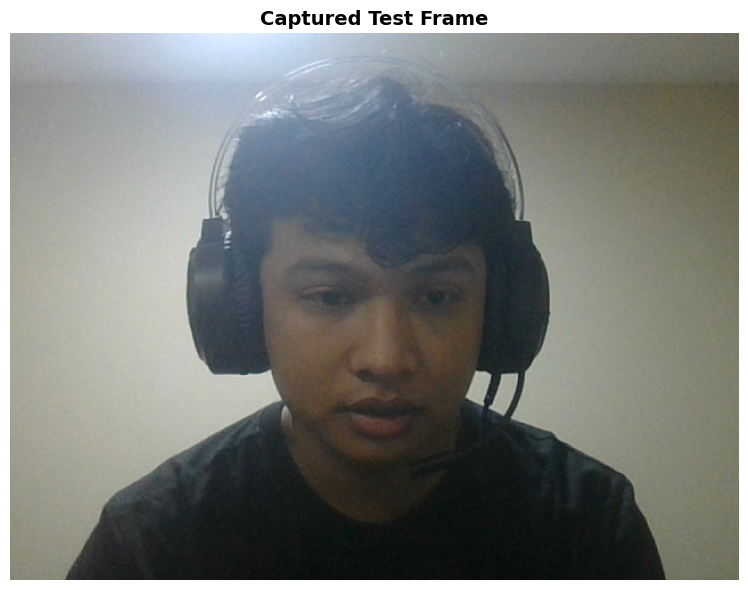

Frame saved for processing


In [8]:
# Open webcam
cap = cv2.VideoCapture(0, cv2.CAP_MSMF)
if not cap.isOpened():
    cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
if not cap.isOpened():
    cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise Exception("Cannot open webcam!")

# Set resolution
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

# Warm up and capture
for _ in range(5):
    cap.read()
    time.sleep(0.1)

ret, test_frame = cap.read()
cap.release()

if not ret or test_frame is None:
    raise Exception("Failed to capture frame!")

print(f"✓ Test frame captured: {test_frame.shape[1]}x{test_frame.shape[0]}")

# Display captured frame
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB))
plt.title("Captured Test Frame", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# Save for later use
np.save('temp_test_frame.npy', test_frame)
print("Frame saved for processing")

## 🎯 Step 4: Process with Model 1 - MediaPipe Pose Only

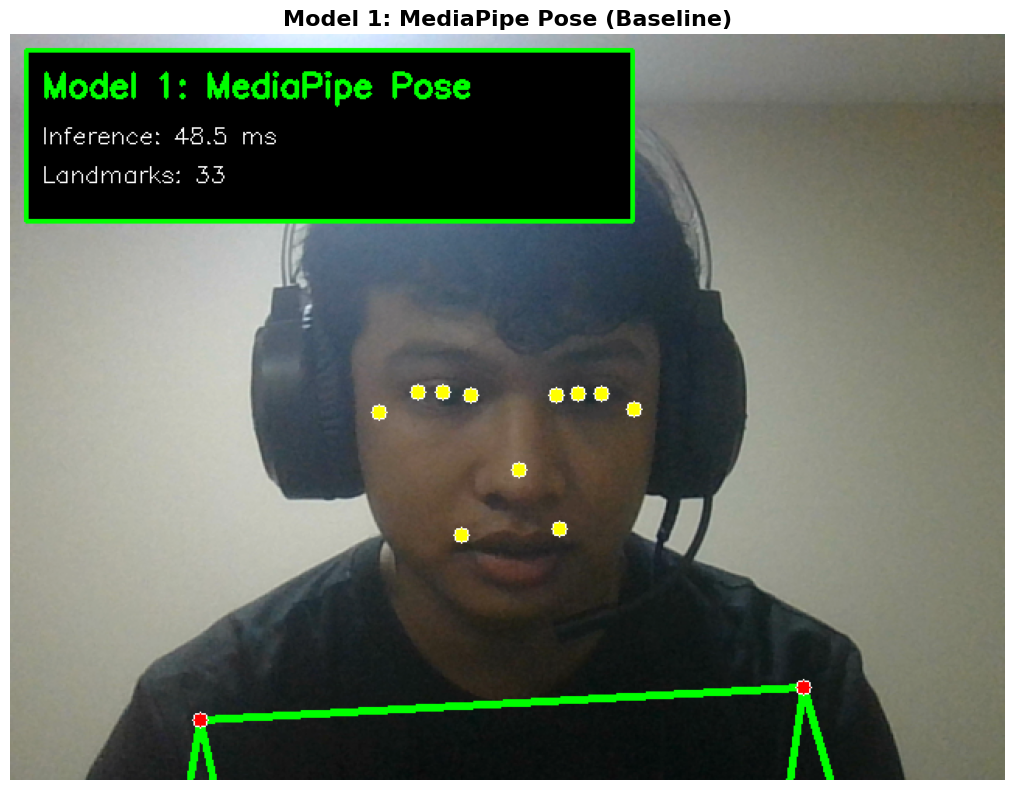

✓ Model 1 Results:
  - Inference Time: 48.50 ms
  - FPS Estimate: 20.6
  - Landmarks Detected: 33


In [9]:
# Load test frame
test_frame = np.load('temp_test_frame.npy')

# Convert to RGB for MediaPipe
rgb_frame = cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

# Process with MediaPipe Pose
start_time = time.time()
pose_result = pose_landmarker.detect(mp_image)
inference_time_1 = (time.time() - start_time) * 1000  # ms

# Visualize
vis_frame_1 = test_frame.copy()
h, w = vis_frame_1.shape[:2]
landmark_count_1 = 0

# Pose connections for skeleton
pose_connections = [
    (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),  # Arms
    (11, 23), (12, 24), (23, 24),                      # Torso
    (23, 25), (25, 27), (24, 26), (26, 28),            # Legs
    (27, 29), (27, 31), (28, 30), (28, 32),            # Feet
]

if pose_result.pose_landmarks:
    for landmarks in pose_result.pose_landmarks:
        landmark_count_1 = len(landmarks)
        
        # Draw skeleton connections
        for s, e in pose_connections:
            if s < len(landmarks) and e < len(landmarks):
                pt1 = (int(landmarks[s].x * w), int(landmarks[s].y * h))
                pt2 = (int(landmarks[e].x * w), int(landmarks[e].y * h))
                cv2.line(vis_frame_1, pt1, pt2, (0, 255, 0), 3)
        
        # Draw keypoints
        for i, lm in enumerate(landmarks):
            color = (0, 255, 255) if i <= 10 else (0, 0, 255)  # Yellow for head, red for body
            cv2.circle(vis_frame_1, (int(lm.x * w), int(lm.y * h)), 5, color, -1)
            cv2.circle(vis_frame_1, (int(lm.x * w), int(lm.y * h)), 5, (255, 255, 255), 1)

# Add info overlay
cv2.rectangle(vis_frame_1, (10, 10), (400, 120), (0, 0, 0), -1)
cv2.rectangle(vis_frame_1, (10, 10), (400, 120), (0, 255, 0), 2)
cv2.putText(vis_frame_1, "Model 1: MediaPipe Pose", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
cv2.putText(vis_frame_1, f"Inference: {inference_time_1:.1f} ms", (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
cv2.putText(vis_frame_1, f"Landmarks: {landmark_count_1}", (20, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

# Display
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(vis_frame_1, cv2.COLOR_BGR2RGB))
plt.title("Model 1: MediaPipe Pose (Baseline)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"✓ Model 1 Results:")
print(f"  - Inference Time: {inference_time_1:.2f} ms")
print(f"  - FPS Estimate: {1000/inference_time_1:.1f}")
print(f"  - Landmarks Detected: {landmark_count_1}")

## 🎯 Step 5: Process with Model 2 - MediaPipe Pose + Face Mesh

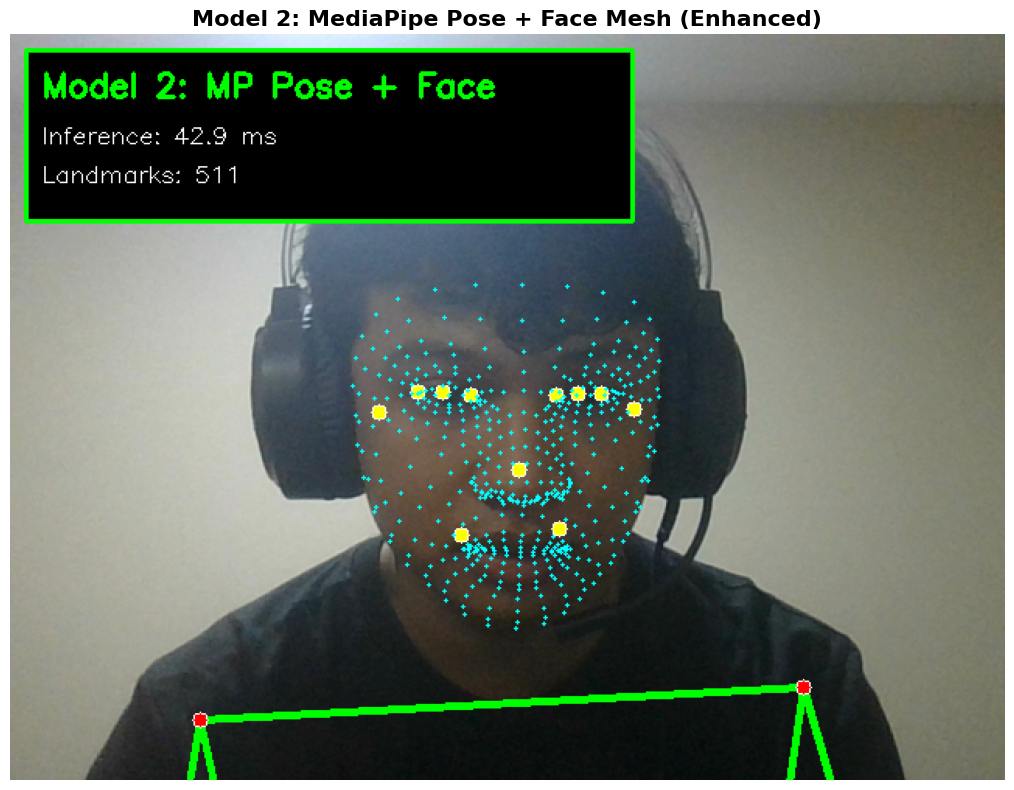

✓ Model 2 Results:
  - Inference Time: 42.94 ms
  - FPS Estimate: 23.3
  - Landmarks Detected: 511


In [10]:
# Load test frame
test_frame = np.load('temp_test_frame.npy')

# Convert to RGB
rgb_frame = cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

# Process with both pose and face
start_time = time.time()
pose_result = pose_landmarker.detect(mp_image)
face_result = face_landmarker.detect(mp_image)
inference_time_2 = (time.time() - start_time) * 1000  # ms

# Visualize
vis_frame_2 = test_frame.copy()
h, w = vis_frame_2.shape[:2]
landmark_count_2 = 0

# Draw pose
if pose_result.pose_landmarks:
    for landmarks in pose_result.pose_landmarks:
        landmark_count_2 += len(landmarks)
        
        # Draw skeleton
        for s, e in pose_connections:
            if s < len(landmarks) and e < len(landmarks):
                pt1 = (int(landmarks[s].x * w), int(landmarks[s].y * h))
                pt2 = (int(landmarks[e].x * w), int(landmarks[e].y * h))
                cv2.line(vis_frame_2, pt1, pt2, (0, 255, 0), 3)
        
        # Draw keypoints
        for i, lm in enumerate(landmarks):
            color = (0, 255, 255) if i <= 10 else (0, 0, 255)
            cv2.circle(vis_frame_2, (int(lm.x * w), int(lm.y * h)), 5, color, -1)
            cv2.circle(vis_frame_2, (int(lm.x * w), int(lm.y * h)), 5, (255, 255, 255), 1)

# Draw face mesh
if face_result.face_landmarks:
    for landmarks in face_result.face_landmarks:
        landmark_count_2 += len(landmarks)
        
        # Draw face points (smaller)
        for lm in landmarks:
            cv2.circle(vis_frame_2, (int(lm.x * w), int(lm.y * h)), 1, (255, 255, 0), -1)

# Add info overlay
cv2.rectangle(vis_frame_2, (10, 10), (400, 120), (0, 0, 0), -1)
cv2.rectangle(vis_frame_2, (10, 10), (400, 120), (0, 255, 0), 2)
cv2.putText(vis_frame_2, "Model 2: MP Pose + Face", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
cv2.putText(vis_frame_2, f"Inference: {inference_time_2:.1f} ms", (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
cv2.putText(vis_frame_2, f"Landmarks: {landmark_count_2}", (20, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

# Display
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(vis_frame_2, cv2.COLOR_BGR2RGB))
plt.title("Model 2: MediaPipe Pose + Face Mesh (Enhanced)", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"✓ Model 2 Results:")
print(f"  - Inference Time: {inference_time_2:.2f} ms")
print(f"  - FPS Estimate: {1000/inference_time_2:.1f}")
print(f"  - Landmarks Detected: {landmark_count_2}")

## 🎯 Step 6: Process with Model 3 - OpenPose

In [11]:
if OPENPOSE_AVAILABLE:
    # Load test frame
    test_frame = np.load('temp_test_frame.npy') 
    
    # Process with OpenPose
    start_time = time.time()
    vis_frame_3, body_kp, face_kp = openpose_detector.process_frame(test_frame)
    inference_time_3 = (time.time() - start_time) * 1000  # ms
    
    landmark_count_3 = openpose_detector.get_landmark_count()
    
    # Add info overlay (if not already added by OpenPose)
    if vis_frame_3 is not None:
        cv2.rectangle(vis_frame_3, (10, 10), (400, 120), (0, 0, 0), -1)
        cv2.rectangle(vis_frame_3, (10, 10), (400, 120), (255, 0, 255), 2)
        cv2.putText(vis_frame_3, "Model 3: OpenPose", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 255), 2)
        cv2.putText(vis_frame_3, f"Inference: {inference_time_3:.1f} ms", (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(vis_frame_3, f"Landmarks: {landmark_count_3}", (20, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        # Display
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(vis_frame_3, cv2.COLOR_BGR2RGB))
        plt.title("Model 3: OpenPose (Industry Standard)", fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Model 3 Results:")
        print(f"  - Inference Time: {inference_time_3:.2f} ms")
        print(f"  - FPS Estimate: {1000/inference_time_3:.1f}")
        print(f"  - Landmarks Detected: {landmark_count_3}")
    else:
        print("✗ OpenPose processing failed")
        inference_time_3 = 0
        landmark_count_3 = 0
else:
    print("⚠ OpenPose not available - skipping Model 3")
    vis_frame_3 = None
    inference_time_3 = 0
    landmark_count_3 = 0

⚠ OpenPose not available - skipping Model 3


## 📊 Step 7: Side-by-Side Comparison

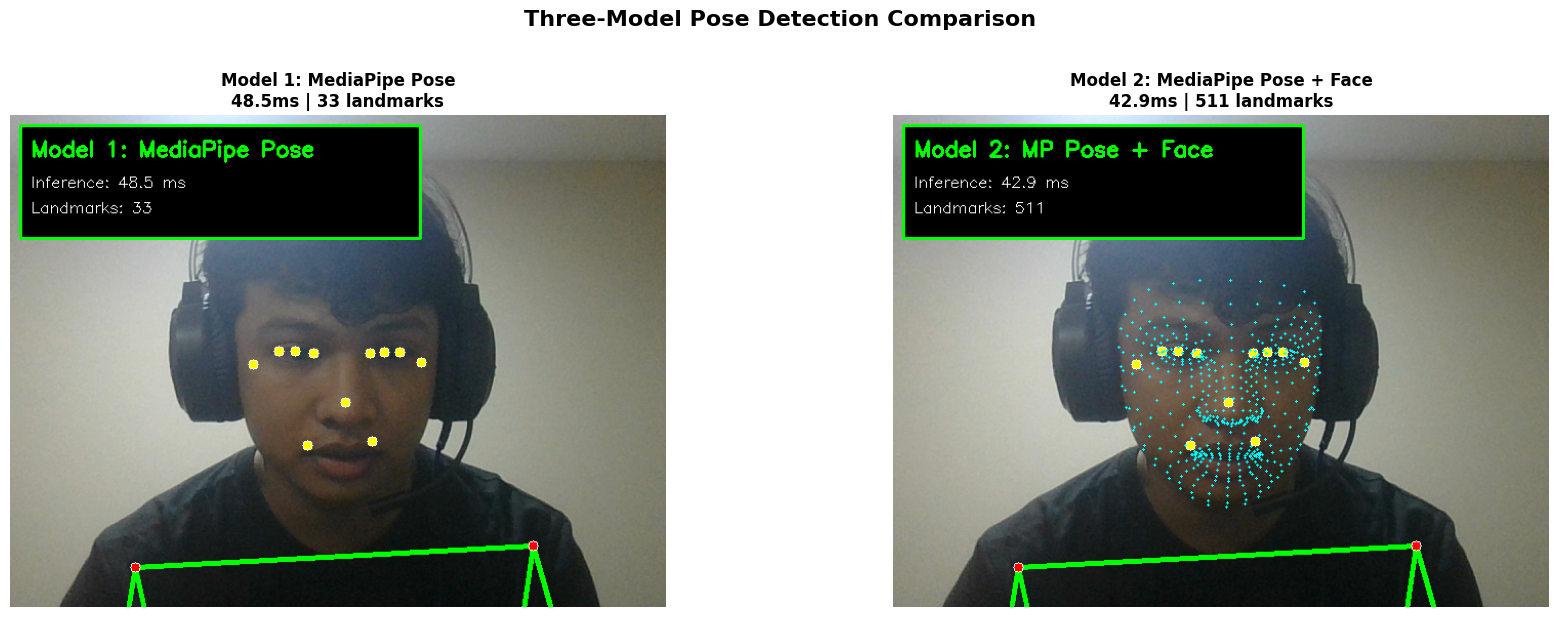

✓ Visual comparison displayed above


In [12]:
# Create side-by-side comparison
num_models = 3 if OPENPOSE_AVAILABLE and vis_frame_3 is not None else 2

fig, axes = plt.subplots(1, num_models, figsize=(18, 6))

if num_models == 2:
    axes = [axes[0], axes[1]]

# Model 1
axes[0].imshow(cv2.cvtColor(vis_frame_1, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Model 1: MediaPipe Pose\n{inference_time_1:.1f}ms | {landmark_count_1} landmarks", 
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# Model 2
axes[1].imshow(cv2.cvtColor(vis_frame_2, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Model 2: MediaPipe Pose + Face\n{inference_time_2:.1f}ms | {landmark_count_2} landmarks", 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

# Model 3 (if available)
if num_models == 3:
    axes[2].imshow(cv2.cvtColor(vis_frame_3, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f"Model 3: OpenPose\n{inference_time_3:.1f}ms | {landmark_count_3} landmarks", 
                      fontsize=12, fontweight='bold')
    axes[2].axis('off')

plt.suptitle("Three-Model Pose Detection Comparison", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Visual comparison displayed above")

## 📈 Step 8: Performance Comparison Table

In [13]:
# Create comparison dataframe
comparison_data = {
    'Model': [
        'MediaPipe Pose',
        'MediaPipe Pose + Face',
    ],
    'Inference Time (ms)': [
        f"{inference_time_1:.2f}",
        f"{inference_time_2:.2f}",
    ],
    'Est. FPS': [
        f"{1000/inference_time_1:.1f}",
        f"{1000/inference_time_2:.1f}",
    ],
    'Landmarks Detected': [
        landmark_count_1,
        landmark_count_2,
    ],
    'Body Points': [33, 33],
    'Face Points': [0, 478]
}

if OPENPOSE_AVAILABLE and inference_time_3 > 0:
    comparison_data['Model'].append('OpenPose')
    comparison_data['Inference Time (ms)'].append(f"{inference_time_3:.2f}")
    comparison_data['Est. FPS'].append(f"{1000/inference_time_3:.1f}")
    comparison_data['Landmarks Detected'].append(landmark_count_3)
    comparison_data['Body Points'].append(25)
    comparison_data['Face Points'].append(70)

df_comparison = pd.DataFrame(comparison_data)

# Display table
print("\n" + "="*80)
print("PERFORMANCE COMPARISON SUMMARY")
print("="*80)
print(df_comparison.to_string(index=False))
print("="*80)

# Display a styled table when possible (requires jinja2).
try:
    import jinja2  # required by pandas Styler
    display(
        df_comparison.style
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}])
    )
except Exception as e:
    print(f"Note: styled table unavailable ({e}). Showing plain DataFrame instead.")
    display(df_comparison)


PERFORMANCE COMPARISON SUMMARY
                Model Inference Time (ms) Est. FPS  Landmarks Detected  Body Points  Face Points
       MediaPipe Pose               48.50     20.6                  33           33            0
MediaPipe Pose + Face               42.94     23.3                 511           33          478


,Model,Inference Time (ms),Est. FPS,Landmarks Detected,Body Points,Face Points
0,MediaPipe Pose,48.50,20.6,33,33,0
1,MediaPipe Pose + Face,42.94,23.3,511,33,478


## 📊 Step 9: Performance Visualization

C:\Users\jingf_81zj\AppData\Local\Temp\ipykernel_13784\3476135483.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=15, ha='right')
C:\Users\jingf_81zj\AppData\Local\Temp\ipykernel_13784\3476135483.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=15, ha='right')


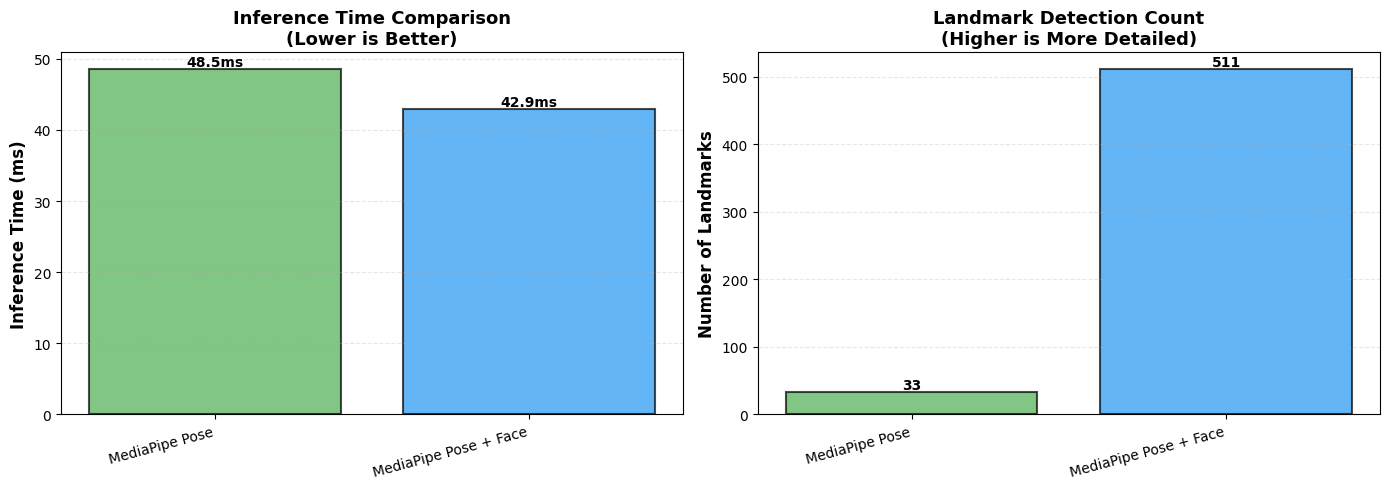

✓ Performance charts displayed above


In [14]:
# Create performance comparison charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = df_comparison['Model'].tolist()
inference_times = [float(x) for x in df_comparison['Inference Time (ms)'].tolist()]
landmarks = df_comparison['Landmarks Detected'].tolist()

# Chart 1: Inference Time
colors = ['#4CAF50', '#2196F3', '#FF9800']
bars1 = ax1.bar(models, inference_times, color=colors[:len(models)], alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Inference Time (ms)', fontsize=12, fontweight='bold')
ax1.set_title('Inference Time Comparison\n(Lower is Better)', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, val in zip(bars1, inference_times):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}ms',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Chart 2: Landmark Count
bars2 = ax2.bar(models, landmarks, color=colors[:len(models)], alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Landmarks', fontsize=12, fontweight='bold')
ax2.set_title('Landmark Detection Count\n(Higher is More Detailed)', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, val in zip(bars2, landmarks):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Rotate x-axis labels
for ax in [ax1, ax2]:
    ax.set_xticklabels(models, rotation=15, ha='right')

plt.tight_layout()
plt.show()

print("✓ Performance charts displayed above")

## 📊 Step 11: Real-Time FPS Benchmark

Run this cell to measure performance metrics over time (no visual display, just FPS tracking).

## 🎥 Step 10: Live Video Tracking Comparison

Run this cell to see **real-time pose detection** with all models running simultaneously.
You'll see yourself in the camera with skeleton overlays from each model side-by-side.

- **Press 'Q'** to quit
- **Press 'S'** to save a screenshot

In [15]:
def run_live_video_comparison():
    """
    Real-time video tracking with all models displayed side-by-side.
    Shows live webcam feed with pose detection from each model.
    """
    print("Starting Live Video Tracking...")
    print("Controls:")
    print("  - Press 'Q' to quit")
    print("  - Press 'S' to save screenshot")
    print("")
    
    # Open webcam
    cap = cv2.VideoCapture(0, cv2.CAP_MSMF)
    if not cap.isOpened():
        cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    if not cap.isOpened():
        cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("ERROR: Cannot open webcam")
        return
    
    # Set resolution
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    
    # Create MediaPipe detectors in VIDEO mode
    base_options_pose_video = python.BaseOptions(model_asset_path=POSE_MODEL_PATH)
    options_pose_video = vision.PoseLandmarkerOptions(
        base_options=base_options_pose_video,
        running_mode=vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )
    pose_detector = vision.PoseLandmarker.create_from_options(options_pose_video)
    
    base_options_face_video = python.BaseOptions(model_asset_path=FACE_MODEL_PATH)
    options_face_video = vision.FaceLandmarkerOptions(
        base_options=base_options_face_video,
        running_mode=vision.RunningMode.VIDEO,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5
    )
    face_detector = vision.FaceLandmarker.create_from_options(options_face_video)
    
    # Pose connections for skeleton drawing
    skeleton_connections = [
        (11, 12), (11, 13), (13, 15), (12, 14), (14, 16),  # Arms
        (11, 23), (12, 24), (23, 24),                      # Torso
        (23, 25), (25, 27), (24, 26), (26, 28),            # Legs
        (27, 29), (27, 31), (28, 30), (28, 32),            # Feet
        (0, 1), (1, 2), (2, 3), (3, 7),                    # Face right
        (0, 4), (4, 5), (5, 6), (6, 8),                    # Face left
        (9, 10),                                            # Mouth
    ]
    
    start_time = time.time()
    frame_count = 0
    fps_1, fps_2, fps_3 = 0, 0, 0
    screenshot_count = 0
    
    print("Live tracking started! Look at the OpenCV window.")
    print("(If no window appears, check your taskbar)")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            continue
        
        frame_count += 1
        timestamp_ms = int((time.time() - start_time) * 1000)
        h, w = frame.shape[:2]
        
        # Convert to RGB for MediaPipe
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        
        # ============ MODEL 1: MediaPipe Pose Only ============
        vis_1 = frame.copy()
        t1 = time.perf_counter()
        pose_result_1 = pose_detector.detect_for_video(mp_image, timestamp_ms)
        fps_1 = 1.0 / max(time.perf_counter() - t1, 0.001)
        
        if pose_result_1.pose_landmarks:
            for landmarks in pose_result_1.pose_landmarks:
                # Draw skeleton
                for s, e in skeleton_connections:
                    if s < len(landmarks) and e < len(landmarks):
                        pt1 = (int(landmarks[s].x * w), int(landmarks[s].y * h))
                        pt2 = (int(landmarks[e].x * w), int(landmarks[e].y * h))
                        cv2.line(vis_1, pt1, pt2, (0, 255, 0), 2)
                # Draw keypoints
                for i, lm in enumerate(landmarks):
                    color = (0, 255, 255) if i <= 10 else (0, 0, 255)
                    cv2.circle(vis_1, (int(lm.x * w), int(lm.y * h)), 4, color, -1)
        
        # Add label
        cv2.rectangle(vis_1, (5, 5), (200, 70), (0, 0, 0), -1)
        cv2.putText(vis_1, "Model 1: Pose", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        cv2.putText(vis_1, f"FPS: {fps_1:.1f}", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(vis_1, "33 landmarks", (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 200, 200), 1)
        
        # ============ MODEL 2: MediaPipe Pose + Face ============
        vis_2 = frame.copy()
        t2 = time.perf_counter()
        pose_result_2 = pose_detector.detect_for_video(mp_image, timestamp_ms + 1)
        face_result_2 = face_detector.detect_for_video(mp_image, timestamp_ms)
        fps_2 = 1.0 / max(time.perf_counter() - t2, 0.001)
        
        landmark_count_2 = 0
        if pose_result_2.pose_landmarks:
            for landmarks in pose_result_2.pose_landmarks:
                landmark_count_2 += len(landmarks)
                # Draw skeleton
                for s, e in skeleton_connections:
                    if s < len(landmarks) and e < len(landmarks):
                        pt1 = (int(landmarks[s].x * w), int(landmarks[s].y * h))
                        pt2 = (int(landmarks[e].x * w), int(landmarks[e].y * h))
                        cv2.line(vis_2, pt1, pt2, (0, 255, 0), 2)
                # Draw keypoints
                for i, lm in enumerate(landmarks):
                    color = (0, 255, 255) if i <= 10 else (0, 0, 255)
                    cv2.circle(vis_2, (int(lm.x * w), int(lm.y * h)), 4, color, -1)
        
        if face_result_2.face_landmarks:
            for landmarks in face_result_2.face_landmarks:
                landmark_count_2 += len(landmarks)
                # Draw face mesh (smaller points)
                for lm in landmarks:
                    cv2.circle(vis_2, (int(lm.x * w), int(lm.y * h)), 1, (255, 255, 0), -1)
        
        # Add label
        cv2.rectangle(vis_2, (5, 5), (220, 70), (0, 0, 0), -1)
        cv2.putText(vis_2, "Model 2: Pose+Face", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 255), 2)
        cv2.putText(vis_2, f"FPS: {fps_2:.1f}", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        cv2.putText(vis_2, f"{landmark_count_2} landmarks", (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 200, 200), 1)
        
        # ============ MODEL 3: OpenPose (if available) ============
        if OPENPOSE_AVAILABLE:
            t3 = time.perf_counter()
            vis_3, _, _ = openpose_detector.process_frame(frame)
            fps_3 = 1.0 / max(time.perf_counter() - t3, 0.001)
            landmark_count_3 = openpose_detector.get_landmark_count()
            
            if vis_3 is None:
                vis_3 = frame.copy()
            
            # Add label
            cv2.rectangle(vis_3, (5, 5), (200, 70), (0, 0, 0), -1)
            cv2.putText(vis_3, "Model 3: OpenPose", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 255), 2)
            cv2.putText(vis_3, f"FPS: {fps_3:.1f}", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            cv2.putText(vis_3, f"{landmark_count_3} landmarks", (10, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 200, 200), 1)
        else:
            # Show placeholder for Model 3
            vis_3 = frame.copy()
            cv2.rectangle(vis_3, (5, 5), (250, 70), (0, 0, 0), -1)
            cv2.putText(vis_3, "Model 3: OpenPose", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (100, 100, 100), 2)
            cv2.putText(vis_3, "(Not Available)", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (100, 100, 100), 1)
        
        # ============ COMBINE ALL VIEWS ============
        # Resize for side-by-side display
        scale = 0.6
        vis_1_small = cv2.resize(vis_1, None, fx=scale, fy=scale)
        vis_2_small = cv2.resize(vis_2, None, fx=scale, fy=scale)
        vis_3_small = cv2.resize(vis_3, None, fx=scale, fy=scale)
        
        # Stack horizontally
        combined = np.hstack([vis_1_small, vis_2_small, vis_3_small])
        
        # Add title bar
        title_bar = np.zeros((40, combined.shape[1], 3), dtype=np.uint8)
        cv2.putText(title_bar, "LIVE POSE DETECTION COMPARISON - Press Q to quit, S to screenshot", 
                    (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        # Combine title with frames
        final_display = np.vstack([title_bar, combined])
        
        # Show window
        cv2.imshow('Live Pose Detection Comparison', final_display)
        
        # Handle key presses
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or key == ord('Q'):
            print("\nQuitting...")
            break
        elif key == ord('s') or key == ord('S'):
            screenshot_count += 1
            filename = f"live_comparison_screenshot_{screenshot_count}.png"
            cv2.imwrite(filename, final_display)
            print(f"Screenshot saved: {filename}")
    
    # Cleanup
    cap.release()
    cv2.destroyAllWindows()
    
    print("\n" + "="*50)
    print("LIVE TRACKING SESSION ENDED")
    print("="*50)
    print(f"Total frames processed: {frame_count}")
    print(f"Duration: {time.time() - start_time:.1f} seconds")
    if screenshot_count > 0:
        print(f"Screenshots saved: {screenshot_count}")
    print("="*50)

# Run the live comparison
print("="*60)
print("STARTING LIVE VIDEO TRACKING")
print("="*60)
print("")
run_live_video_comparison()

STARTING LIVE VIDEO TRACKING

Starting Live Video Tracking...
Controls:
  - Press 'Q' to quit
  - Press 'S' to save screenshot

Live tracking started! Look at the OpenCV window.
(If no window appears, check your taskbar)

Quitting...

LIVE TRACKING SESSION ENDED
Total frames processed: 1008
Duration: 72.9 seconds



REAL-TIME PERFORMANCE RESULTS
Total frames: 150
Duration: 10.0s

Model 1 (MediaPipe Pose Only):
  Average Time: 24.38 ms
  Average FPS: 41.0
  Min FPS: 27.5
  Max FPS: 48.6

Model 2 (MediaPipe Pose + Face):
  Average Time: 36.06 ms
  Average FPS: 27.7
  Min FPS: 18.5
  Max FPS: 32.6


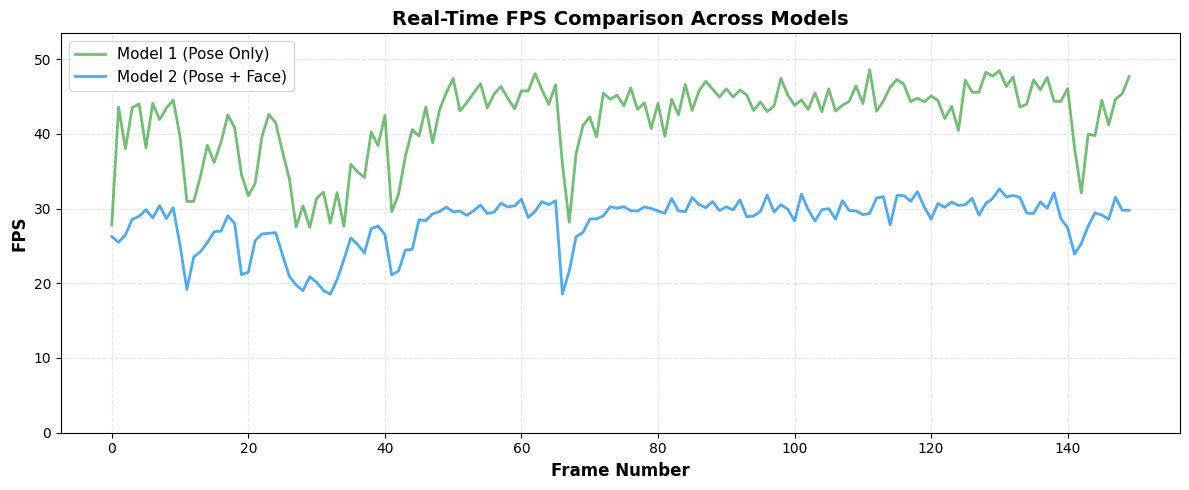

In [16]:
def run_realtime_comparison(duration_seconds=10):
    """
    Run real-time comparison for a specified duration.
    Shows all 3 models processing the same frame simultaneously.
    """
    print("Starting real-time comparison...")
    print(f"Duration: {duration_seconds} seconds")
    print("Press 'Q' to quit early\n")
    
    # Open webcam
    cap = cv2.VideoCapture(0, cv2.CAP_MSMF)
    if not cap.isOpened():
        cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)
    if not cap.isOpened():
        cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("ERROR: Cannot open webcam")
        return
    
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    
    # Reinitialize MediaPipe for VIDEO mode
    base_options_pose_video = python.BaseOptions(model_asset_path=POSE_MODEL_PATH)
    options_pose_video = vision.PoseLandmarkerOptions(
        base_options=base_options_pose_video,
        running_mode=vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_tracking_confidence=0.5
    )
    pose_landmarker_video = vision.PoseLandmarker.create_from_options(options_pose_video)
    
    base_options_face_video = python.BaseOptions(model_asset_path=FACE_MODEL_PATH)
    options_face_video = vision.FaceLandmarkerOptions(
        base_options=base_options_face_video,
        running_mode=vision.RunningMode.VIDEO,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5
    )
    face_landmarker_video = vision.FaceLandmarker.create_from_options(options_face_video)
    
    start_time_global = time.time()
    frame_count = 0
    
    # Performance tracking - measure inference time in ms for more accuracy
    time_list_1 = []  # Model 1: Pose only
    time_list_2 = []  # Model 2: Pose + Face combined
    time_list_3 = []  # Model 3: OpenPose
    
    print("Recording...")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            continue
        
        frame_count += 1
        timestamp_ms = int((time.time() - start_time_global) * 1000)
        
        # Process with all models
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        
        # Model 1 - Pose only
        t1 = time.perf_counter()
        pose_result = pose_landmarker_video.detect_for_video(mp_image, timestamp_ms)
        elapsed_1 = (time.perf_counter() - t1) * 1000  # ms
        time_list_1.append(elapsed_1)
        
        # Model 2 - Pose + Face combined
        t2 = time.perf_counter()
        _ = pose_landmarker_video.detect_for_video(mp_image, timestamp_ms + 1)  # +1 to avoid same timestamp
        face_result = face_landmarker_video.detect_for_video(mp_image, timestamp_ms)
        elapsed_2 = (time.perf_counter() - t2) * 1000  # ms
        time_list_2.append(elapsed_2)
        
        # Model 3 (if available)
        if OPENPOSE_AVAILABLE:
            t3 = time.perf_counter()
            _, _, _ = openpose_detector.process_frame(frame)
            elapsed_3 = (time.perf_counter() - t3) * 1000  # ms
            time_list_3.append(elapsed_3)
        
        # Check duration
        elapsed = time.time() - start_time_global
        if elapsed >= duration_seconds:
            break
        
        # Display progress
        if frame_count % 10 == 0:
            clear_output(wait=True)
            print(f"Recording... {elapsed:.1f}s / {duration_seconds}s")
            print(f"Frames captured: {frame_count}")
            if len(time_list_1) > 0:
                avg_fps_1 = 1000 / max(np.mean(time_list_1), 0.1)
                print(f"Model 1 Avg FPS: {avg_fps_1:.1f}")
            if len(time_list_2) > 0:
                avg_fps_2 = 1000 / max(np.mean(time_list_2), 0.1)
                print(f"Model 2 Avg FPS: {avg_fps_2:.1f}")
            if len(time_list_3) > 0:
                avg_fps_3 = 1000 / max(np.mean(time_list_3), 0.1)
                print(f"Model 3 Avg FPS: {avg_fps_3:.1f}")
    
    cap.release()
    
    # Convert times to FPS (with min clamp to avoid division issues)
    fps_list_1 = [1000 / max(t, 0.1) for t in time_list_1]
    fps_list_2 = [1000 / max(t, 0.1) for t in time_list_2]
    fps_list_3 = [1000 / max(t, 0.1) for t in time_list_3] if time_list_3 else []
    
    # Display results
    clear_output(wait=True)
    print("\n" + "="*60)
    print("REAL-TIME PERFORMANCE RESULTS")
    print("="*60)
    print(f"Total frames: {frame_count}")
    print(f"Duration: {elapsed:.1f}s")
    print()
    
    if len(time_list_1) > 0:
        avg_time_1 = np.mean(time_list_1)
        avg_fps_1 = 1000 / max(avg_time_1, 0.1)
        print(f"Model 1 (MediaPipe Pose Only):")
        print(f"  Average Time: {avg_time_1:.2f} ms")
        print(f"  Average FPS: {avg_fps_1:.1f}")
        print(f"  Min FPS: {np.min(fps_list_1):.1f}")
        print(f"  Max FPS: {np.max(fps_list_1):.1f}")
        print()
    
    if len(time_list_2) > 0:
        avg_time_2 = np.mean(time_list_2)
        avg_fps_2 = 1000 / max(avg_time_2, 0.1)
        print(f"Model 2 (MediaPipe Pose + Face):")
        print(f"  Average Time: {avg_time_2:.2f} ms")
        print(f"  Average FPS: {avg_fps_2:.1f}")
        print(f"  Min FPS: {np.min(fps_list_2):.1f}")
        print(f"  Max FPS: {np.max(fps_list_2):.1f}")
    
    if len(fps_list_3) > 0:
        avg_time_3 = np.mean(time_list_3)
        avg_fps_3 = 1000 / max(avg_time_3, 0.1)
        print()
        print(f"Model 3 (OpenPose):")
        print(f"  Average Time: {avg_time_3:.2f} ms")
        print(f"  Average FPS: {avg_fps_3:.1f}")
        print(f"  Min FPS: {np.min(fps_list_3):.1f}")
        print(f"  Max FPS: {np.max(fps_list_3):.1f}")
    
    print("="*60)
    
    # Plot FPS over time
    plt.figure(figsize=(12, 5))
    if len(fps_list_1) > 0:
        plt.plot(fps_list_1, label='Model 1 (Pose Only)', color='#4CAF50', linewidth=2, alpha=0.8)
    if len(fps_list_2) > 0:
        plt.plot(fps_list_2, label='Model 2 (Pose + Face)', color='#2196F3', linewidth=2, alpha=0.8)
    if len(fps_list_3) > 0:
        plt.plot(fps_list_3, label='Model 3 (OpenPose)', color='#FF9800', linewidth=2, alpha=0.8)
    
    plt.xlabel('Frame Number', fontsize=12, fontweight='bold')
    plt.ylabel('FPS', fontsize=12, fontweight='bold')
    plt.title('Real-Time FPS Comparison Across Models', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3, linestyle='--')
    
    # Set reasonable y-axis limits
    all_fps = fps_list_1 + fps_list_2 + fps_list_3
    if all_fps:
        plt.ylim(0, min(max(all_fps) * 1.1, 500))  # Cap at 500 FPS for readability
    
    plt.tight_layout()
    plt.show()

# Run comparison for 10 seconds
run_realtime_comparison(duration_seconds=10)

## 💾 Step 12: Save Comparison Report

In [17]:
# Save comparison report
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
report_file = f"notebook_comparison_report_{timestamp}.txt"

with open(report_file, 'w') as f:
    f.write("="*70 + "\n")
    f.write("THREE-MODEL POSE DETECTION COMPARISON REPORT\n")
    f.write("="*70 + "\n\n")
    f.write(f"Date: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Test Type: Single Frame Analysis\n\n")
    
    f.write("Models Compared:\n")
    f.write("  1. MediaPipe Pose (Baseline)\n")
    f.write("  2. MediaPipe Pose + Face Mesh (Enhanced)\n")
    if OPENPOSE_AVAILABLE:
        f.write("  3. OpenPose (Industry Standard)\n")
    f.write("\n")
    
    f.write("Performance Summary:\n")
    f.write("-" * 70 + "\n")
    f.write(df_comparison.to_string(index=False))
    f.write("\n" + "-" * 70 + "\n\n")
    
    f.write("Analysis:\n")
    f.write(f"  - Fastest Model: Model 1 (MediaPipe Pose)\n")
    f.write(f"  - Most Detailed: Model 2 (MediaPipe Pose + Face)\n")
    if OPENPOSE_AVAILABLE:
        f.write(f"  - Industry Standard: Model 3 (OpenPose)\n")
    f.write("\n")
    
    f.write("Conclusions:\n")
    f.write("  - Model 1 provides fast body tracking for real-time applications\n")
    f.write("  - Model 2 adds detailed face landmarks with moderate performance impact\n")
    if OPENPOSE_AVAILABLE:
        f.write("  - Model 3 offers comprehensive detection with higher computational cost\n")
    f.write("\n")
    f.write("="*70 + "\n")

print(f"✓ Report saved to: {report_file}")

# Also save comparison dataframe to CSV
csv_file = f"notebook_comparison_{timestamp}.csv"
df_comparison.to_csv(csv_file, index=False)
print(f"✓ CSV data saved to: {csv_file}")

✓ Report saved to: notebook_comparison_report_20260207_170840.txt
✓ CSV data saved to: notebook_comparison_20260207_170840.csv


## 🎓 Conclusions and Recommendations

### Summary

This notebook compared three pose detection systems:

1. **MediaPipe Pose** - Best for speed, suitable for real-time body tracking
2. **MediaPipe Pose + Face Mesh** - Best balance of detail and performance
3. **OpenPose** - Industry standard, most comprehensive (if available)

### Recommendations

- **Real-time applications**: Use Model 1 for maximum FPS
- **Face analysis required**: Use Model 2 for detailed facial features
- **Benchmark comparison**: Use Model 3 (OpenPose) as industry baseline

### Next Steps

1. Test with different poses and scenarios
2. Evaluate accuracy with ground truth data (if available)
3. Test on different hardware (CPU vs GPU)
4. Consider model fusion for optimal results

---

## 🧹 Cleanup

In [18]:
# Clean up temporary files created by this notebook
if os.path.exists('temp_test_frame.npy'):
    os.remove('temp_test_frame.npy')
    print("✓ Temporary files cleaned up")

print("\n" + "="*70)
print("NOTEBOOK COMPARISON COMPLETE")
print("="*70)
print("\nOutputs saved in this folder:")
print("  - report_*.txt")
print("  - notebook_comparison_*.csv")
print("="*70)

✓ Temporary files cleaned up

NOTEBOOK COMPARISON COMPLETE

Outputs saved in this folder:
  - report_*.txt
  - notebook_comparison_*.csv
